# Planetary Mass Inversion: The Double-Shot Predictor-Corrector Pipeline

Converting observed telescopic flux and estimated stellar age into a planetary mass is one of the most difficult inversions in astrophysics. Because planetary flux spans many orders of magnitude and decays exponentially over time, standard interpolation fails. Furthermore, different planetary masses have drastically different physical uncertainties (e.g., cloud variance).

This notebook demonstrates the **Double-Shot Mass Inverter**, a pipeline that natively handles:
1. **Heteroscedastic Errors:** Understanding that physical uncertainty changes depending on the planet's mass.
2. **Orthogonal Error Decomposition:** Separating the timeline (Age) uncertainty from structural (Radius/EOS) uncertainty.
3. **Multi-Dimensional Scaling:** Seamlessly processing scalars, 1D profiles, or massive 2D detection images.

In [2]:
%matplotlib inline

import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Ensure Python can find local modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor
from cooltrack.mass_mapper import DoubleShotMassInverter

## Step 1: The Error Profiles (Calibration)

Before we invert any pixels, the pipeline must calibrate itself to the specific star system being observed. Standard models assume a flat "instrumental error" across the entire image. However, physical reality dictates that a 1 $M_J$ planet has a very different uncertainty profile than a 20 $M_J$ brown dwarf.

During initialization, the inverter builds **Localized Error Profiles** composed of three components:
1. **Instrumental Noise ($\sigma_{inst}$):** The base variance of the JWST/telescope observation.
2. **Surrogate Noise ($\sigma_{surr}$):** The uncertainty stemming from our piecewise surrogate fits.
3. **Grid Gap Noise ($\sigma_{gap}$):** The interpolation error caused by the discrete spacing of the underlying physics grid (e.g., the jump from 5 $M_J$ to 10 $M_J$).

These are combined in quadrature to create a dynamic variance profile: $\sigma_{total}^2 = \sigma_{inst}^2 + \sigma_{surr}^2 + \sigma_{gap}^2$

In [4]:
print("Booting Oracle Predictor...")
oracle = CoolTrackPredictor("../data/cooltrack_coefficients.dat", "../data/age_data")

# System specific parameters
SYSTEM_AGE_YR = 5000e6
AGE_ERROR_YR = SYSTEM_AGE_YR * 0.10 
SYSTEM_DIST_PC = 22.4793
OBSERVED_BAND = 'JWST/MIRI.F1500W'  

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': -0.2, 'core': 10.0, 
    'kzz': 8.0, 'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# 1. Initialize and calibrate the engine (This triggers the Error Profile generation)
inverter = DoubleShotMassInverter(
    oracle=oracle,
    distance_pc=SYSTEM_DIST_PC,
    system_age_yr=SYSTEM_AGE_YR,
    observed_band=OBSERVED_BAND,
    fixed_params=FIXED_PARAMS
)

Booting Oracle Predictor...


2026-05-09 11:16:05,305 - INFO - Loaded initial condition interpolators from 8 files.


Calibrating Inverter for Dist: 22.4793 pc | Age: 5000.0 Myr
Calibration complete in 17.7s.


## Step 2: The Double-Shot Logic

How do we apply a mass-dependent error to a pixel when we don't know the pixel's mass yet? 
We use a **Predictor-Corrector (Double-Shot)** algorithm.

### Shot 1: The Predictor (Deterministic)
We take the raw flux image and map it through a dense, 2D Clough-Tocher interpolation surface generated from the Oracle grid. This provides a "First Guess" mass for every pixel. 

Because we now have a First Guess mass, we can query our localized error profiles to determine exactly how much physical variance ($\sigma_{total}$) belongs to that specific pixel!

### Shot 2: The Corrector (Monte Carlo)
We unleash a 100-draw Monte Carlo engine:
1. We draw 100 variations of the Star's Age (representing Thermodynamic uncertainty).
2. We draw 100 variations of the Image Flux (representing Instrumental + Surrogate + Gap uncertainty).
3. We push all 100 perturbed universes through the inverse spline, resulting in a 3D data cube `(100, height, width)`.

Finally, we collapse the cube along the Z-axis, extracting the 50th percentile (Median Mass) and the difference between the 84th and 50th percentiles (+1$\sigma$ Mass Error).

In [16]:
# Generate a Mock FITS image to represent our telescopic data
limit_jy = np.linspace(1e-6, 1e-5, 250) + np.random.normal(0, 1e-6, (250, 250))

# Add a mock "bright source" central spike
y, x = np.mgrid[0:250, 0:250]
limit_jy += 1e-5 * np.exp(-((y - 125)**2 + (x - 125)**2) / 20.0)

# Convert to W/m^2/um
c = 2.9979e8  
wavelength_m = 15e-6  
limit_w_m2_um = limit_jy * 1e-26 * (c / (wavelength_m**2)) * 1e-6

print("Executing Double-Shot Predictor-Corrector Inversion...")
# The inverter natively handles the 2D array, broadcasting the logic across all pixels
mass_map, err_map = inverter.get_mass(flux_w_m2_um=limit_w_m2_um, age_err_yr=AGE_ERROR_YR, n_draws=100)

Executing Double-Shot Predictor-Corrector Inversion...


/Users/cwilkinson/Documents/Work/Research/Research/Codes/cooltrack/src/cooltrack/mass_mapper.py:160: RuntimeWarning: invalid value encountered in log10
  flat_fluxes = np.log10(flux_array.flatten())


Processed 6250000 evaluations in 8.31s.


## Step 3: Visualization

Because we strictly bounded our surrogate fits against the laws of thermodynamics (e.g., clipping at the "Hot Start" entropy ceiling and tracking the convex hull), our maps are safe from exponential blow-ups.

Pixels that fall outside the physically valid hull are safely mapped to `np.nan` or boundary markers, allowing for clean, rigorous detection limit maps.

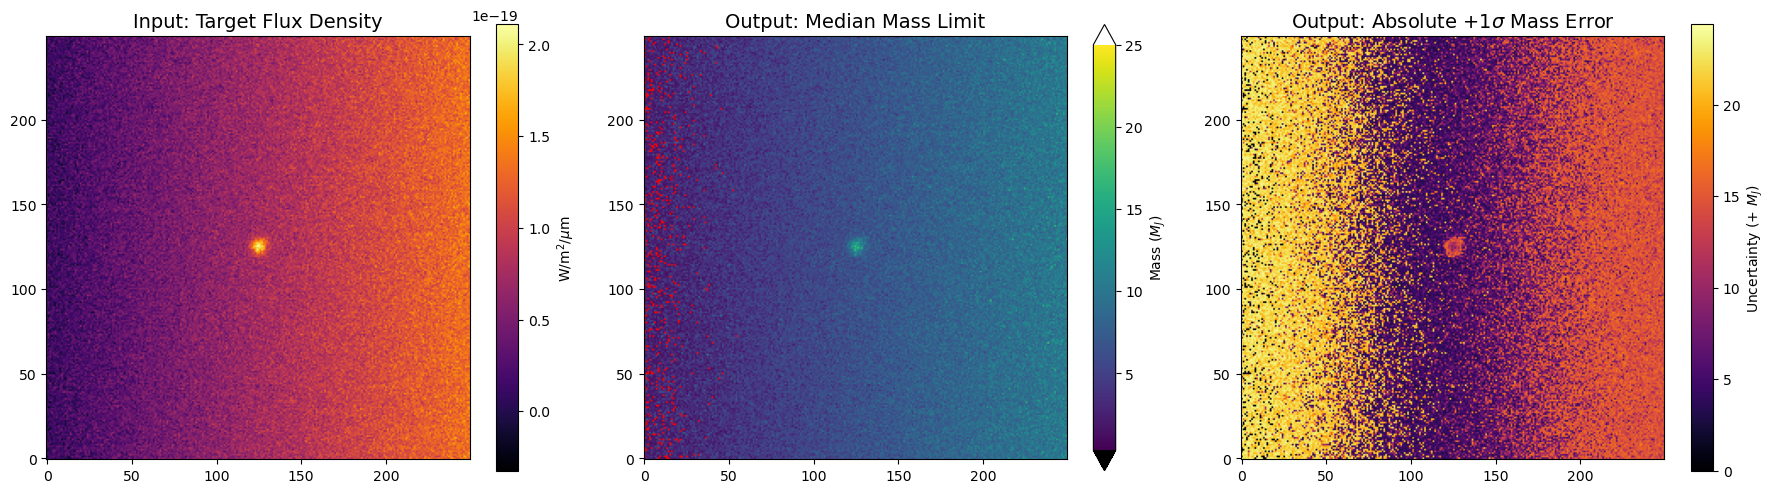

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Input Flux
im0 = axes[0].imshow(limit_w_m2_um, cmap='inferno', origin='lower')
axes[0].set_title("Input: Target Flux Density", fontsize=14)
plt.colorbar(im0, ax=axes[0], label='W/m$^2$/$\mu$m')

# Panel 2: Mass Limit Map
cmap_mass = copy.copy(plt.cm.viridis)
cmap_mass.set_under('black')   
cmap_mass.set_over('white')    
cmap_mass.set_bad('red')       

im1 = axes[1].imshow(mass_map, cmap=cmap_mass, origin='lower', 
                     vmin=inverter.actual_min_mass, vmax=inverter.actual_max_mass)
axes[1].set_title("Output: Median Mass Limit", fontsize=14)
plt.colorbar(im1, ax=axes[1], label='Mass ($M_J$)', extend='both')

# Panel 3: Uncertainty Map
cmap_err = copy.copy(plt.cm.inferno)
cmap_err.set_bad('black') 
im2 = axes[2].imshow(err_map, cmap=cmap_err, origin='lower', vmin=0.0)
axes[2].set_title("Output: Absolute +1$\sigma$ Mass Error", fontsize=14)
plt.colorbar(im2, ax=axes[2], label='Uncertainty (+ $M_J$)')

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 1. READ & CONVERT THE OBSERVATION
# ==========================================
print("Loading observation data...")
FITS_FILE = "../data/detlim_mjup_l-231-32_obs-20_sub-sub256_date-2024-02-10_filter-f1500w_pid-03730_dither-none_uid-V03730020001P0000000003101d0o20_merged-cal_nobkg.fits"

if not os.path.exists(FITS_FILE):
    print("--> FITS not found. Generating mock 250x250 observation...")
    limit_jy = np.linspace(1e-5, 5e-5, 250) + np.random.normal(0, 1e-6, (250, 250))
    # Add a mock "bright source" detection limit spike in the center
    limit_jy += 1e-4 * np.exp(-((np.mgrid[0:250, 0:250][1] - 125)**2 + (np.mgrid[0:250, 0:250][0] - 125)**2) / 20.0)
    
    SYSTEM_AGE_YR = 5000e6
    SYSTEM_DIST_PC = 22.4793
    SYSTEM_MET = -0.2
else:
    print("--> Loading real FITS data...")
    with fits.open(FITS_FILE) as hdul:
        limit_jy = hdul[1].data
        hdr = hdul[0].header
        SYSTEM_AGE_YR = float(hdr['AGE_MYR']) * 1e6
        SYSTEM_DIST_PC = float(hdr['DISTANCE_PC'])
        SYSTEM_MET = float(hdr['MET_DEX'])

# Unit Conversion (Jy -> W/m^2/um)
c = 2.9979e8  
wavelength_m = 15e-6  
limit_w_m2_um = limit_jy * 1e-26 * (c / (wavelength_m**2)) * 1e-6


FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': 0, 'core': 10.0, 
    'kzz': 8.0, 'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

OBSERVED_BAND = 'JWST/MIRI.F1500W' 

print("Booting Oracle Predictor...")
oracle = CoolTrackPredictor("../data/cooltrack_coefficients.dat", "../data/age_data")

# 1. Initialize and calibrate the engine (This triggers the Error Profile generation)
inverter = DoubleShotMassInverter(
    oracle=oracle,
    distance_pc=SYSTEM_DIST_PC,
    system_age_yr=SYSTEM_AGE_YR,
    observed_band=OBSERVED_BAND,
    fixed_params=FIXED_PARAMS,
    min_mass=1,
    max_mass=50.0
)

Loading observation data...
--> Loading real FITS data...
Booting Oracle Predictor...


2026-05-27 14:39:59,116 - INFO - Loaded initial condition interpolators from 8 files.


Calibrating Inverter for Dist: 22.4793 pc | Age: 5000.0 Myr
Calibration complete in 15.9s.


In [8]:
AGE_ERROR_YR = 1

print("Executing Double-Shot Predictor-Corrector Inversion...")
mass_map, err_map = inverter.get_mass(flux_w_m2_um=limit_w_m2_um, age_err_yr=AGE_ERROR_YR, n_draws=100)

Executing Double-Shot Predictor-Corrector Inversion...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Processed 6250000 evaluations in 10.70s.


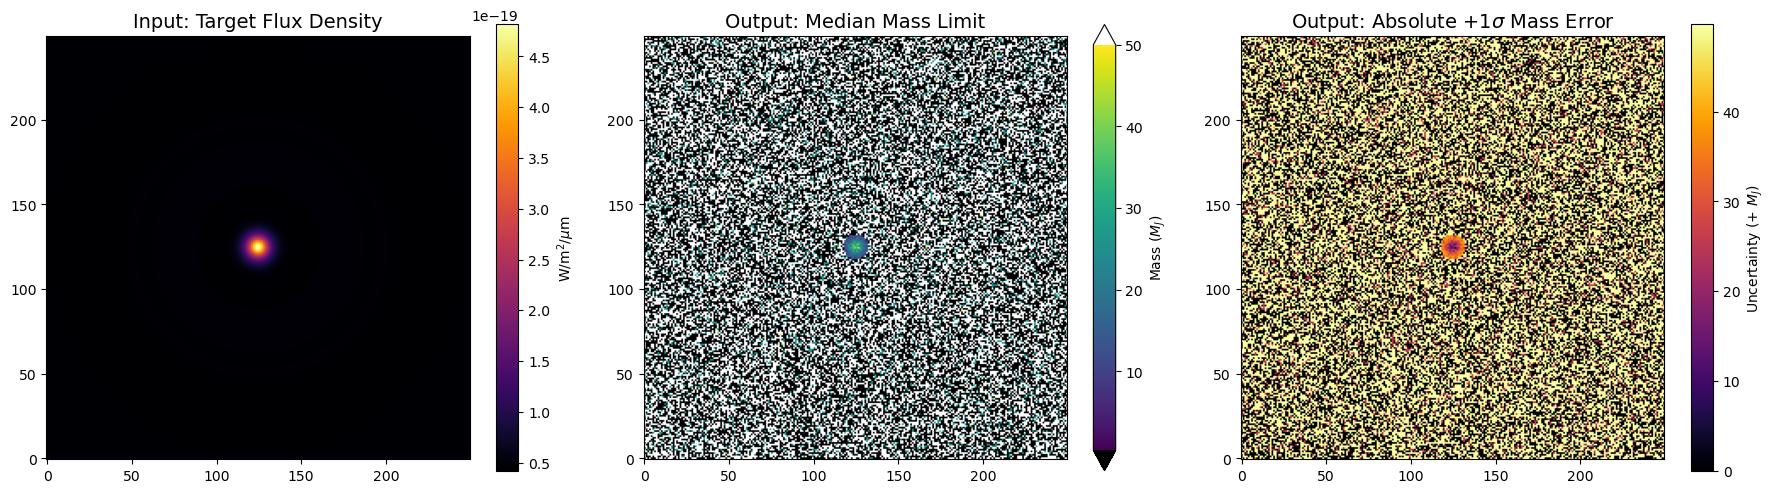

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Input Flux
im0 = axes[0].imshow(limit_w_m2_um, cmap='inferno', origin='lower')
axes[0].set_title("Input: Target Flux Density", fontsize=14)
plt.colorbar(im0, ax=axes[0], label='W/m$^2$/$\mu$m')

# Panel 2: Mass Limit Map
cmap_mass = copy.copy(plt.cm.viridis)
cmap_mass.set_under('black')   
cmap_mass.set_over('white')    
cmap_mass.set_bad('red')       

im1 = axes[1].imshow(mass_map, cmap=cmap_mass, origin='lower', 
                     vmin=inverter.actual_min_mass, vmax=inverter.actual_max_mass)
axes[1].set_title("Output: Median Mass Limit", fontsize=14)
plt.colorbar(im1, ax=axes[1], label='Mass ($M_J$)', extend='both')

# Panel 3: Uncertainty Map
cmap_err = copy.copy(plt.cm.inferno)
cmap_err.set_bad('black') 
im2 = axes[2].imshow(err_map, cmap=cmap_err, origin='lower', vmin=0.0)
axes[2].set_title("Output: Absolute +1$\sigma$ Mass Error", fontsize=14)
plt.colorbar(im2, ax=axes[2], label='Uncertainty (+ $M_J$)')

plt.tight_layout()
plt.show()

Booting Oracle Predictor for Baseline Evolution...


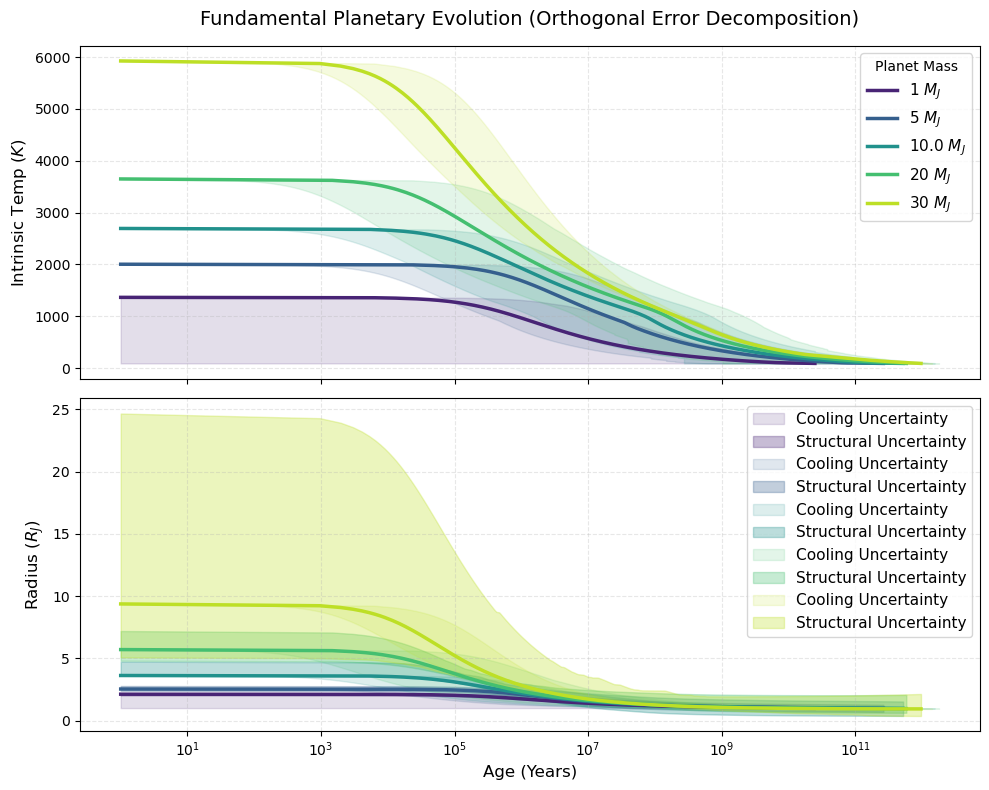

In [10]:
# ==============================================================================
# CELL 1: SIMPLE EVOLUTION CURVES (ORTHOGONAL ERROR DECOMPOSITION)
# ==============================================================================
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

print("Booting Oracle Predictor for Baseline Evolution...")

masses_to_test = [1, 5, 10.0, 20, 30]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(masses_to_test)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i, mass in enumerate(masses_to_test):
    query_vec = np.array([mass, 100.0, 0.0, 10.0, 6.0, 6.0, 8.0]) 
    scaled_query = (query_vec - oracle.mean) / oracle.std
    
    _, idx = oracle.tree.query(scaled_query)
    cached_fits = oracle.database[int(idx)]
    
    # Extract the complete evolutionary track 
    track = oracle.engine.evolve(cached_fits, start_type=19, n_draws=100)
    
    # Enforce monotonic time to prevent plot overlapping
    for col in ['age_yr', 'age_yr_lower', 'age_yr_upper']:
        track[col] = track[col].clip(lower=1.0) 
        track[col] = np.maximum.accumulate(track[col])
        
    # Create a safe upper bound that never crosses below the median (for Hot Starts)
    safe_age_upper = np.maximum(track['age_yr'], track['age_yr_upper'])

    # ==========================================
    # 4A. TEMPERATURE: Bounded by Time Uncertainty
    # ==========================================
    ax1.plot(track['age_yr'], track['T_int'], color=colors[i], lw=2.5, label=f"{mass} $M_J$")
    ax1.fill_betweenx(track['T_int'], track['age_yr_lower'], safe_age_upper, color=colors[i], alpha=0.15)
    
    # ==========================================
    # 4B. RADIUS: Orthogonal Error Decomposition
    # ==========================================
    ax2.plot(track['age_yr'], track['Req_Rj'], color=colors[i], lw=2.5)
    
    # X-Axis Error: Thermodynamic / Cooling Uncertainty
    ax2.fill_betweenx(track['Req_Rj'], track['age_yr_lower'], safe_age_upper, 
                      color=colors[i], alpha=0.15, label='Cooling Uncertainty')
    
    # Y-Axis Error: Structural / Equation of State Uncertainty
    # (Because the arrays are now perfectly stable, we can plot them directly!)
    ax2.fill_between(track['age_yr'], track['Req_Rj_lower'], track['Req_Rj_upper'], 
                     color=colors[i], alpha=0.3, label='Structural Uncertainty')

# Format Top Panel: Intrinsic Temperature
ax1.set_title('Fundamental Planetary Evolution (Orthogonal Error Decomposition)', fontsize=14, pad=15)
ax1.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax1.set_xscale('log')
ax1.legend(title="Planet Mass", fontsize=11)
ax1.grid(True, alpha=0.3, ls='--')

# Format Bottom Panel: Structural Radius
ax2.set_xlabel('Age (Years)', fontsize=12)
ax2.set_ylabel('Radius ($R_J$)', fontsize=12)
ax2.set_xscale('log')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, ls='--')

plt.tight_layout()
plt.show()